# SOB4ES - Modelo Random Forest

### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluación de los modelos

Este notebook recorre el ciclo de vida completo del modelo Random Forest.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por país)
- `test.csv` - Búsqueda de hiperparámetros y validación cruzada (15 %)
- `eval.csv` - Evaluación final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. **Configuración:** importaciones y parámetros globales.
2. **Carga de datos:** se cargan los tres splits pre-generados.
3. **Tuning:** búsqueda del valor óptimo de los hiperparámetros.
4. **Validación cruzada:** evaluación de robustez.
5. **Explicabilidad (SHAP):** análisis de importancia de variables.
6. **Producción:** entrenamiento final y exportación de modelos.
7. **Evaluación final:** rendimiento real sobre `eval.csv`.

## 1.- Configuración del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.

In [1]:
import os
import time
import warnings
import joblib
import math
import pandas as pd
import numpy as np
from pathlib import Path

import itertools
from matplotlib.colors import LinearSegmentedColormap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import shap
import matplotlib.pyplot as plt

# ignoramos los warnings
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/rf/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

TARGETS = [
    # Shannon 
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')

# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}
# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Librerias y variables cargadas correctamente...


In [2]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 16 | n_jobs asignado: 12


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la división 70/15/15 estratificada por país.

| Archivo     | Uso                                      | Filas aprox. |
| ----------- | ---------------------------------------- | ------------ |
| `train.csv` | Ajuste del modelo                        | 299          |
| `test.csv`  | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv`  | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la sección 7 para garantizar una estimación imparcial del rendimiento.

In [3]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3.- Busqueda de hiperparámetros (Tuning)

Se realiza una búsqueda aleatoria (`RandomizedSearchCV`) sobre el espacio de hiperparámetros de `RandomForestRegressor`. 
La búsqueda se ejecuta exclusivamente sobre `X_train`. 
Como variable objetivo de referencia se usa `earthworm_shannon_z`.

Principales hiperparametros explorados:
- **`n_estimators`:** número de árboles en el bosque.
- **`max_depth`:** profundidad máxima de cada árbol.
- **`min_samples_split` / `min_samples_leaf`:** criterios de parada para la división de nodos.
- **`max_features`:** número de variables consideradas en cada split.
- **`bootstrap`:** si se usa muestreo con reemplazamiento.

Para reducir el riesgo de sobreajuste con un dataset pequeño (~300 muestras), el grid se restringe de la siguiente forma: 
- **`max_depth`:** maximo 20.
- **`min_samples_leaf`:** mínimo 2.
- **`bootstrap=True`:** para mayor variabilidad entre árboles.

Iniciando busqueda de hiperparametros (Tuning) para cada target...
Este proceso puede tardar varios minutos...


[ 1/21] | [nematode_shannon_z       ] R2 CV: 0.2266 | Tiempo:  5.5s


[ 2/21] | [macro_shannon_z          ] R2 CV: 0.2735 | Tiempo:  4.2s


[ 3/21] | [earthworm_shannon_z      ] R2 CV: 0.4652 | Tiempo:  4.2s


[ 4/21] | [orib_shannon_z           ] R2 CV: 0.1023 | Tiempo:  4.2s


...

[17/21] | [bac_asv_richness_z       ] R2 CV: 0.0818 | Tiempo:  5.0s


[18/21] | [fun_asv_richness_z       ] R2 CV: -0.0313 | Tiempo:  5.0s


[19/21] | [euk_asv_richness_z       ] R2 CV: 0.2320 | Tiempo:  5.0s


[20/21] | [oomy_asv_richness_z      ] R2 CV: 0.2423 | Tiempo:  4.9s


[21/21] | [cerc_asv_richness_z      ] R2 CV: 0.1944 | Tiempo:  5.0s

Busqueda de hiperparametros completada en 1.7 minutos...


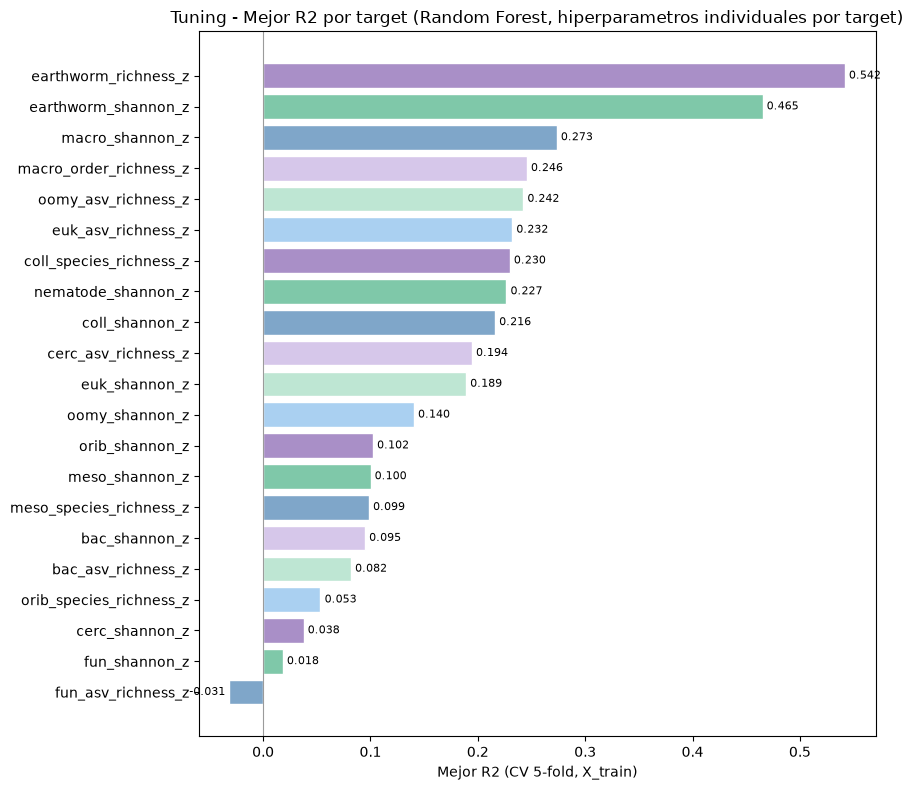

In [4]:
print('Iniciando busqueda de hiperparametros (Tuning) para cada target...')
print('Este proceso puede tardar varios minutos...')
param_grid = {
	'n_estimators':      [100, 150, 200],
	'max_depth':         [3, 4, 5, 10, 15, 20],
	'min_samples_leaf':  [2, 4, 8, 12, 16],
	'min_samples_split': [15, 20, 25],
	'max_features':      ['sqrt', 0.2, 0.3],
	'ccp_alpha':         [0.005, 0.01, 0.02],
	'bootstrap':         [True],
	'random_state':      [RANDOM_STATE]
}

resultados_tuning = {}
RF_OPTIMAL_PARAMS_PER_TARGET = {}
start_total = time.time()

for idx, target_col in enumerate(TARGETS, 1):
    y_prueba = y_train[target_col].values
    t0 = time.time()

    buscador = RandomizedSearchCV(
        estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions=param_grid,
        n_iter=50,
        scoring='r2',
        cv=5,
        verbose=0,
        random_state=RANDOM_STATE,
        n_jobs= N_JOBS
    )
    buscador.fit(X_train, y_prueba)
    elapsed = time.time() - t0

    mejores_params = dict(buscador.best_params_)
    mejores_params['n_jobs'] = -1

    resultados_tuning[target_col] = {
        'params': mejores_params,
        'r2':     buscador.best_score_,
    }
    RF_OPTIMAL_PARAMS_PER_TARGET[target_col] = mejores_params

    print(f"[{idx:2d}/{len(TARGETS)}] | [{target_col:<25}] R2 CV: {buscador.best_score_:.4f} | Tiempo: {time.time()-t0:>4.1f}s")

print(f'\nBusqueda de hiperparametros completada en {(time.time() - start_total)/60:.1f} minutos...')

# Grafico: mejor R2 de tuning obtenido para cada uno de los 21 targets
r2_tuning_por_target = pd.Series({t: v['r2'] for t, v in resultados_tuning.items()}).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
_bars = ax.barh(r2_tuning_por_target.index, r2_tuning_por_target.values,
                 color=palette_cycle(len(r2_tuning_por_target)), edgecolor='white')
ax.bar_label(_bars, fmt='{:.3f}', padding=3, fontsize=8)
ax.set_xlabel('Mejor R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target (Random Forest, hiperparametros individuales por target)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

## 4.- Validación cruzada

Se evalua la robustez del modelo mediante **validación cruzada repetida** (5 pliegues x 3 repeticiones = 15 evaluaciones) sobre `X_train`. 

Comparando el rendimiento en entrenamiento y en validación se puede detectar sobreajuste, algo especialmente relevante en Random Forest dado que puede memorizar los datos de entrenamiento con facilidad.

In [5]:
print('Validacion cruzada repetida sobre X_train...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

resultados_cv_por_target = {}

# Impresión del encabezado de la tabla
header = f"{'TARGET':<26} | {'TRAIN R2':<10} | {'CV R2':<10} | {'DIFF':<10} | {'ESTADO'}"
print(header)
print('-' * len(header))

for target_col in TARGETS:
    y_prueba = y_train[target_col].values

    modelo_cv = RandomForestRegressor(
        **RF_OPTIMAL_PARAMS_PER_TARGET[target_col],
    )
    
    resultados = cross_validate(
        estimator=modelo_cv,
        X=X_train,
        y=y_prueba,
        cv=cv_splitter,
        scoring=metricas,
        return_train_score=True,
        n_jobs=N_JOBS
    )

    r2_train   = np.mean(resultados['train_r2'])
    r2_cv      = np.mean(resultados['test_r2'])
    diferencia = r2_train - r2_cv

    resultados_cv_por_target[target_col] = {'train_r2': r2_train, 'cv_r2': r2_cv}

    estado = "Aviso: Posible sobreajuste" if diferencia > 0.15 else "OK"

    print(f"{target_col:<26} | {r2_train:<10.3f} | {r2_cv:<10.3f} | {diferencia:<10.3f} | {estado}")

Validacion cruzada repetida sobre X_train...

TARGET                     | TRAIN R2   | CV R2      | DIFF       | ESTADO
--------------------------------------------------------------------------


nematode_shannon_z         | 0.539      | 0.261      | 0.278      | Aviso: Posible sobreajuste


macro_shannon_z            | 0.611      | 0.282      | 0.329      | Aviso: Posible sobreajuste


earthworm_shannon_z        | 0.694      | 0.434      | 0.261      | Aviso: Posible sobreajuste


orib_shannon_z             | 0.441      | 0.106      | 0.335      | Aviso: Posible sobreajuste


...

bac_asv_richness_z         | 0.403      | 0.048      | 0.355      | Aviso: Posible sobreajuste


fun_asv_richness_z         | 0.251      | -0.022     | 0.274      | Aviso: Posible sobreajuste


euk_asv_richness_z         | 0.576      | 0.219      | 0.358      | Aviso: Posible sobreajuste


oomy_asv_richness_z        | 0.579      | 0.248      | 0.331      | Aviso: Posible sobreajuste


cerc_asv_richness_z        | 0.519      | 0.233      | 0.286      | Aviso: Posible sobreajuste


## 5.- Explicabilidad del modelo (SHAP)

Se utiliza SHAP (`TreeExplainer`) para analizar la importancia de las variables predictoras. `TreeExplainer` es compatible con `RandomForestRegressor` y calcula los valores de Shapley de forma exacta.

Interpretación del gráfico:
- Las variables se ordenan de mayor a menor importancia global.
- El color indica el valor de la variable (rojo = valor alto, azul = valor bajo).
- La posición horizontal indica el efecto sobre la predicción.

Posteriormente, se agrupan los datos de SHAP para obtener las variables más relevantes ordenadas de más relevantes a menos dentro de un top 10.

Calculando valores SHAP sobre X_train para TODOS los targets...



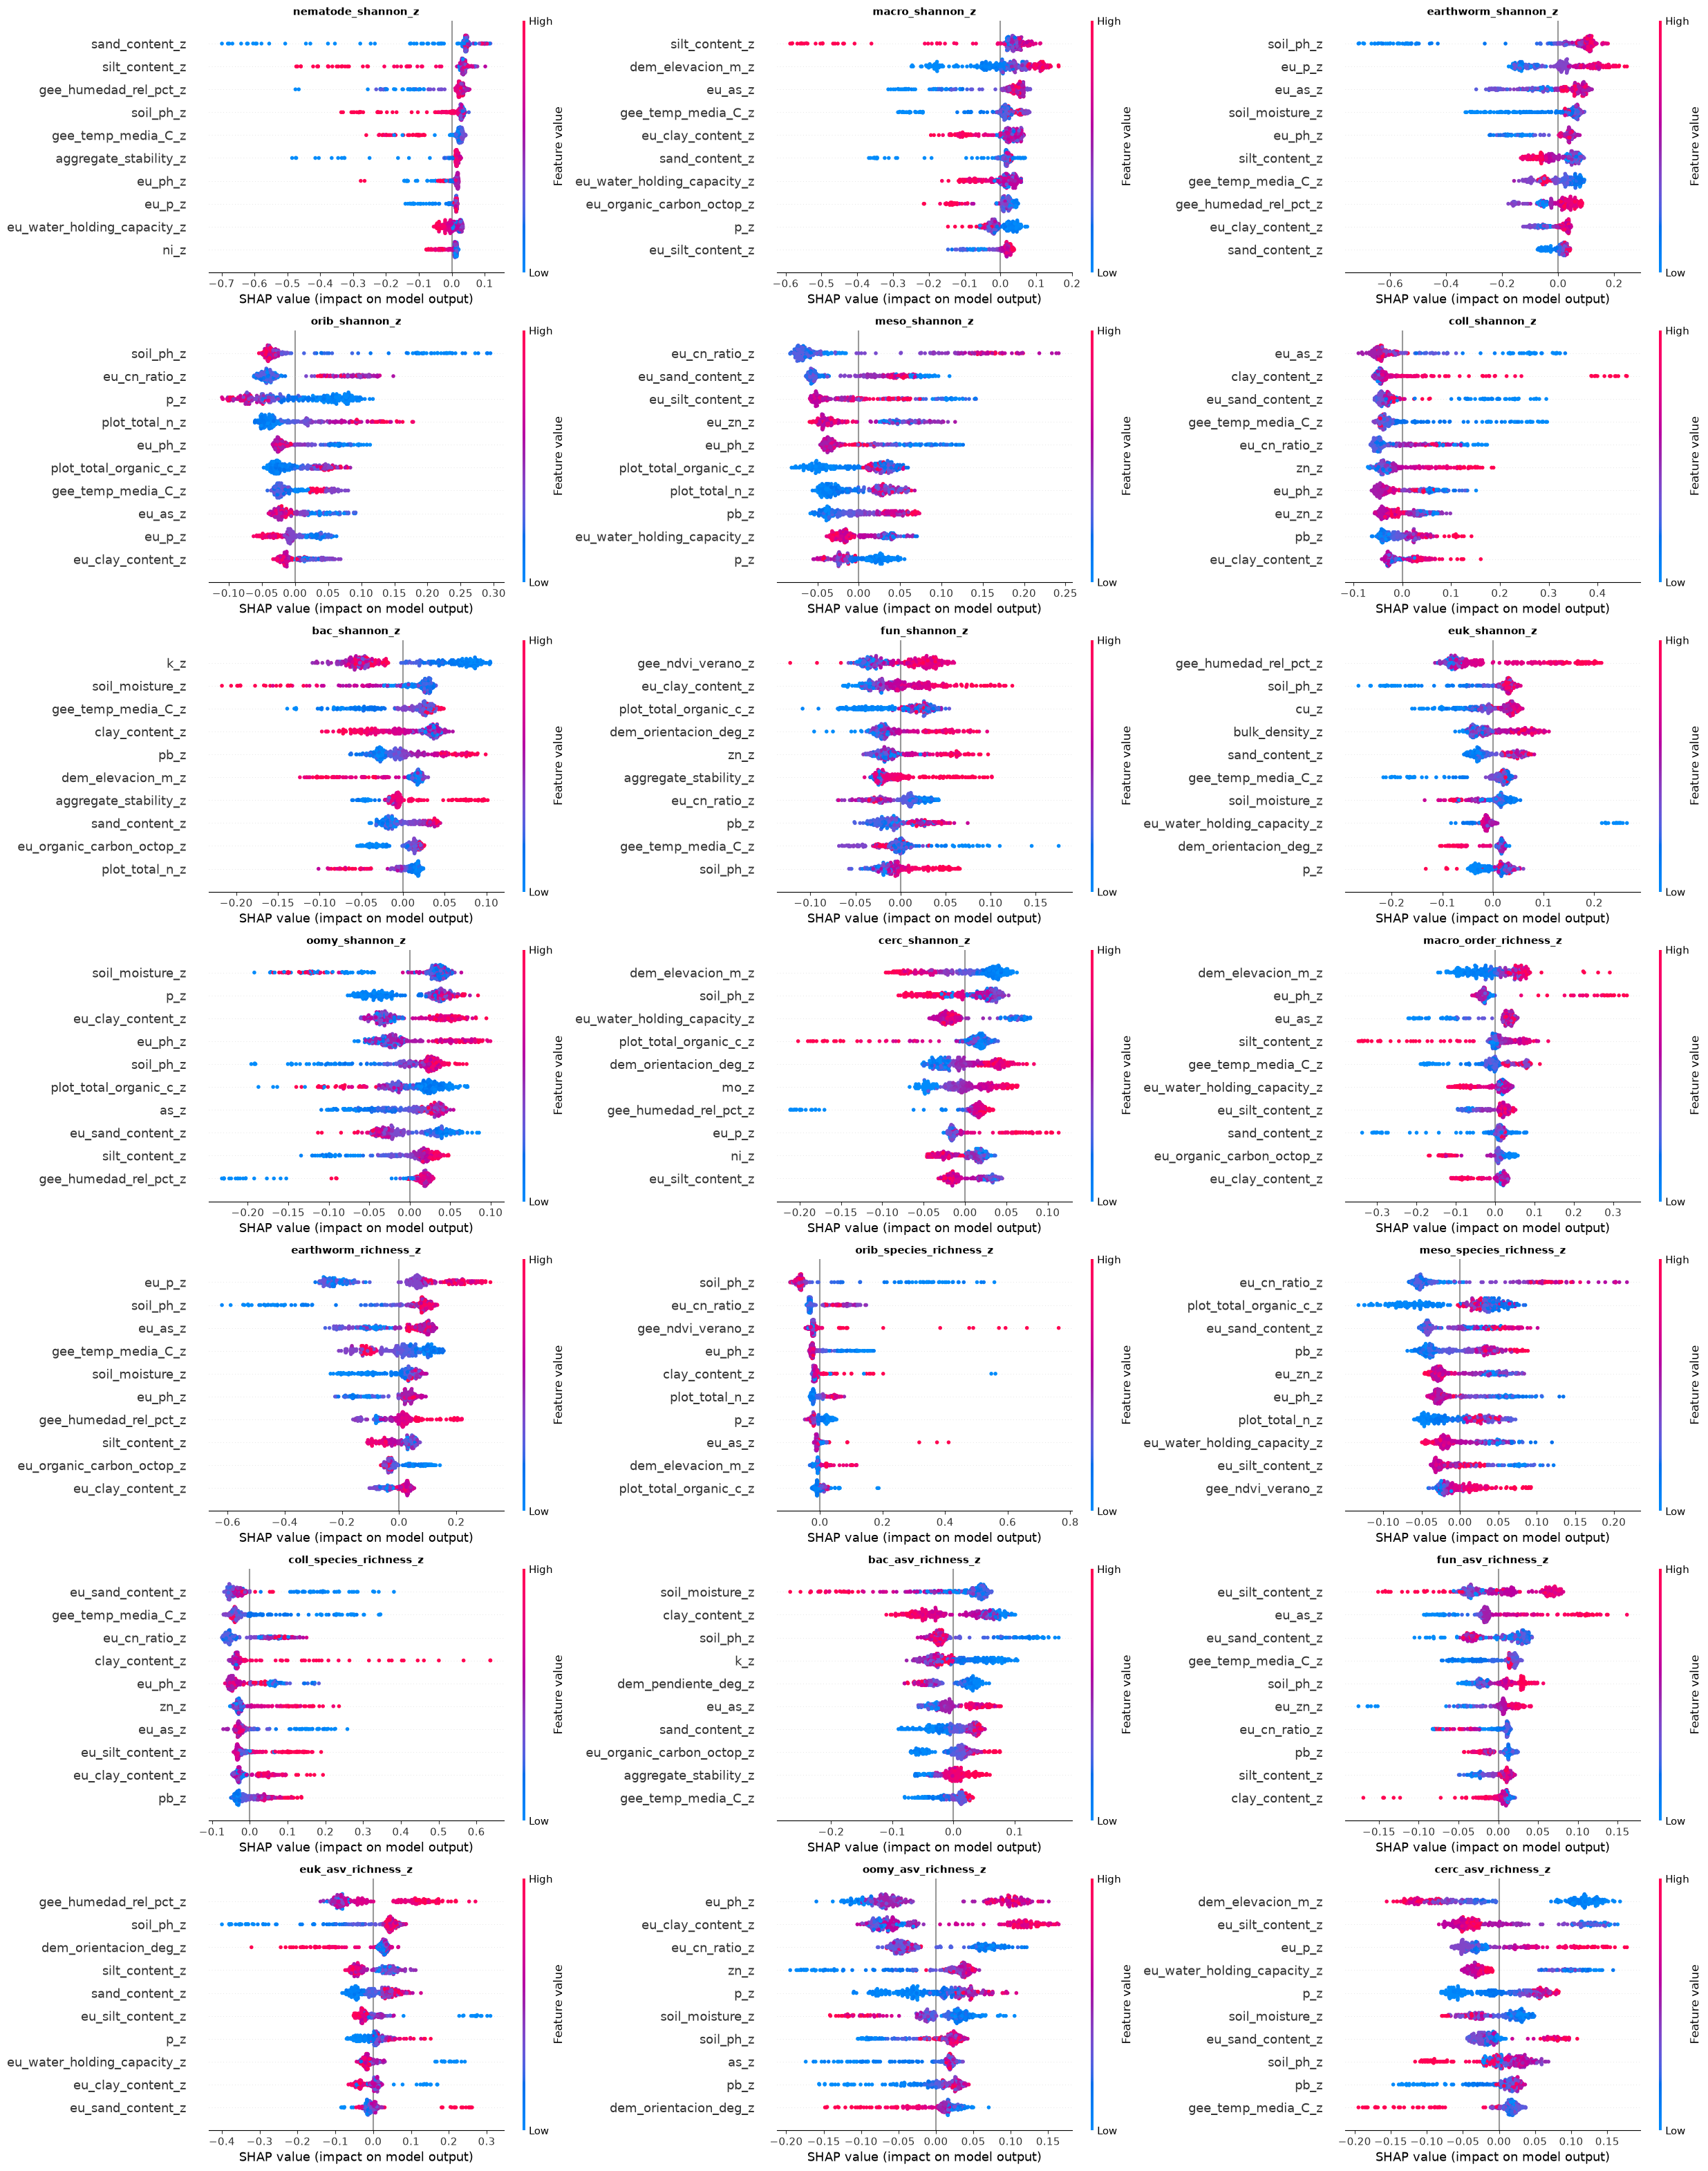


Top 10 variables MÁS importantes por SHAP (Promedio Global de Targets):
soil_ph_z                0.0425
gee_temp_media_C_z       0.0318
eu_ph_z                  0.0313
eu_as_z                  0.0311
eu_cn_ratio_z            0.0284
gee_humedad_rel_pct_z    0.0280
eu_p_z                   0.0254
eu_clay_content_z        0.0248
silt_content_z           0.0245
eu_silt_content_z        0.0239


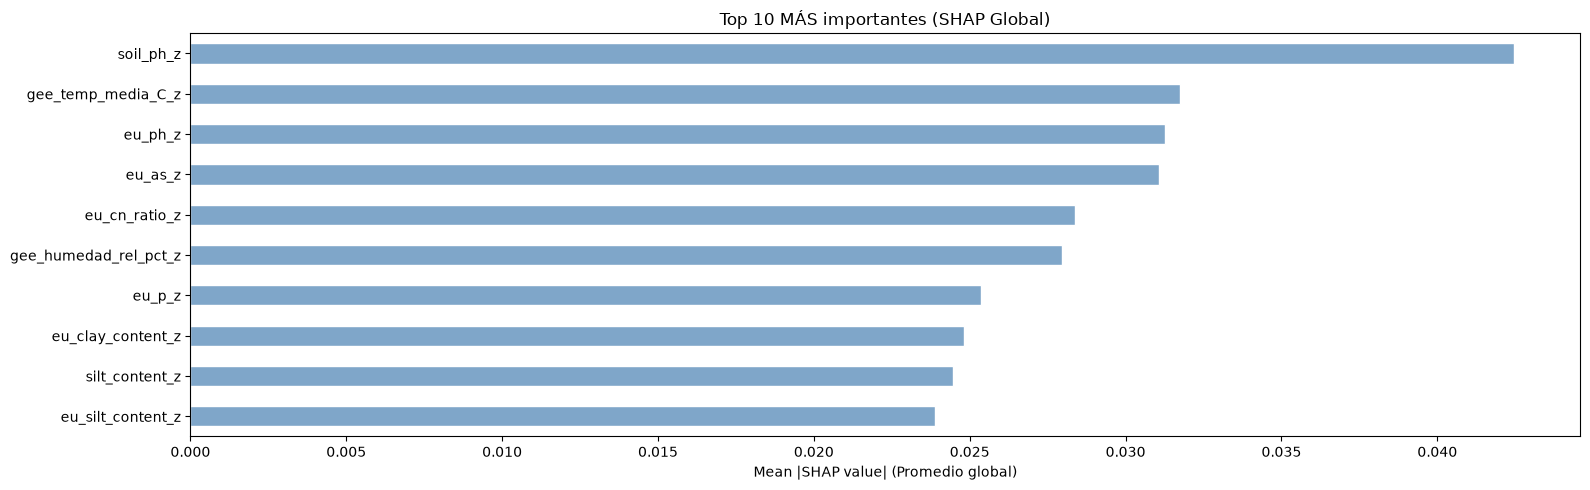

In [6]:
print('Calculando valores SHAP sobre X_train para TODOS los targets...\n')

all_shap_means = []
n_targets = len(TARGETS)
n_cols = 3
n_rows = math.ceil(n_targets / n_cols)

# Crear el grid de subplots (5 columnas x N filas)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 4.5 * n_rows))
axes_flat = axes.flatten()

for i, tgt in enumerate(TARGETS):
    # Modelo específico para cada target
    modelo_shap = RandomForestRegressor(
        **RF_OPTIMAL_PARAMS_PER_TARGET[tgt],
    )
    modelo_shap.fit(X_train, y_train[tgt].values)
    
    # Cálculo de SHAP
    explainer = shap.TreeExplainer(modelo_shap)
    shap_values = explainer.shap_values(X_train)
    
    # Renderizado en el subplot asignado dentro del grid
    plt.sca(axes_flat[i])
    shap.summary_plot(
        shap_values, 
        X_train, 
        plot_type='dot', 
        max_display=10, 
        show=False, 
        plot_size=None
    )
    axes_flat[i].set_title(tgt, fontsize=11, fontweight='bold')
    
    # Acumular la importancia absoluta media
    mean_abs_tgt = np.abs(shap_values).mean(axis=0)
    all_shap_means.append(mean_abs_tgt)

# Ocultar los subplots sobrantes en el grid
for j in range(n_targets, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

# Promedio global integrando todos los targets
global_shap_mean = np.mean(all_shap_means, axis=0)
shap_importance_series = pd.Series(global_shap_mean, index=FEATURES_AUTORIZADAS)

# Extraer Top 10 variables más y menos importantes a nivel global
top10_shap = shap_importance_series.nlargest(10)

print('\nTop 10 variables MÁS importantes por SHAP (Promedio Global de Targets):')
print(top10_shap.round(4).to_string())

# Gráficos comparativos globales de barras
fig, axes_bar = plt.subplots(1, 1, figsize=(16, 5))

# Gráfico A: Más importantes
top10_shap.sort_values().plot(kind='barh', ax=axes_bar, color=PALETTE['blue'], edgecolor='white')
axes_bar.set_title('Top 10 MÁS importantes (SHAP Global)', fontsize=12)
axes_bar.set_xlabel('Mean |SHAP value| (Promedio global)')
axes_bar.set_ylabel('')

plt.tight_layout()
plt.show()

## 6.- Entrenamiento

Se entrena un ensamble de 5 modelos por cada variable objetivo, variando la semilla aleatoria (semilla + n_modelo). 

Esto complementa la aleatoridad intrinseca de Random Forest y reduce la varianza de las predicciones finales. 

Todos los modelos se guardan en disco en formato `.pkl`.

In [7]:
print('Entrenamiento de produccion (ensamble de 5 modelos por target)...')
print('-' * 70)

global_start = time.time()
NUM_MODELOS  = 5

for idx, target_col in enumerate(TARGETS, 1):
    t0 = time.time()
    y  = y_train[target_col].values

    for seed_id in range(NUM_MODELOS):
        params = RF_OPTIMAL_PARAMS_PER_TARGET[target_col].copy()
        params['random_state'] = RANDOM_STATE + seed_id

        model = RandomForestRegressor(**params)
        model.fit(X_train, y)

        joblib.dump(model, os.path.join(MODELS_DIR, f'rf_prod_{target_col}_m{seed_id}.pkl'))

    print(f'  [{idx}/{len(TARGETS)}] {target_col:30} completado ({time.time()-t0:.1f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time() - global_start)/60:.1f} minutos...')
print(f'Modelos guardados: {len(TARGETS) * NUM_MODELOS} ({NUM_MODELOS} por target)...')
print('Cada target fue entrenado con su propia configuración de hiperparametros...')


Entrenamiento de produccion (ensamble de 5 modelos por target)...
----------------------------------------------------------------------


  [1/21] nematode_shannon_z             completado (0.6s)


  [2/21] macro_shannon_z                completado (0.6s)


  [3/21] earthworm_shannon_z            completado (0.6s)


  [4/21] orib_shannon_z                 completado (0.4s)


...

  [17/21] bac_asv_richness_z             completado (0.6s)


  [18/21] fun_asv_richness_z             completado (0.4s)


  [19/21] euk_asv_richness_z             completado (0.4s)


  [20/21] oomy_asv_richness_z            completado (0.4s)


  [21/21] cerc_asv_richness_z            completado (0.8s)
----------------------------------------------------------------------
Produccion completada en 0.2 minutos...
Modelos guardados: 105 (5 por target)...
Cada target fue entrenado con su propia configuración de hiperparametros...


In [8]:
# PRUEBA 3 - Barrido de random_state (100-5000 en saltos de 10)

RANDOM_STATES = range(100, 5001, 10)
dir_barrido   = os.path.join(MODELS_DIR, 'barrido_rs_rf')
os.makedirs(dir_barrido, exist_ok=True)

resultados_rs = []
t_inicio = time.time()

for rs in RANDOM_STATES:
    t0 = time.time()
    fila = {'random_state': rs}

    for target_col in TARGETS:
        params = RF_OPTIMAL_PARAMS_PER_TARGET[target_col].copy()
        params['random_state'] = rs   # fuerza explícitamente el rs del barrido

        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train[target_col].values)

        y_pred = model.predict(X_eval)
        y_true = y_eval[target_col].values

        fila[f'{target_col}_r2']   = r2_score(y_true, y_pred)
        fila[f'{target_col}_rmse'] = np.sqrt(mean_squared_error(y_true, y_pred))
        fila[f'{target_col}_mae']  = mean_absolute_error(y_true, y_pred)

        joblib.dump(model, os.path.join(dir_barrido, f'rf_prod_{target_col}_rs{rs}.pkl'))

    resultados_rs.append(fila)
    if rs % 10 == 0:
        print(f'  rs={rs:3d} completado ({time.time()-t0:.1f}s)')

df_barrido_rf = pd.DataFrame(resultados_rs)
df_barrido_rf.to_csv(os.path.join(dir_barrido, 'rf_barrido_rs.csv'), index=False)
print(f'\nBarrido completado en {(time.time()-t_inicio)/60:.1f} minutos.')

  rs=100 completado (2.8s)


  rs=110 completado (2.8s)


  rs=120 completado (2.9s)


  rs=130 completado (2.8s)


  rs=140 completado (2.9s)


...

  rs=4960 completado (2.8s)


  rs=4970 completado (2.8s)


  rs=4980 completado (2.8s)


  rs=4990 completado (2.8s)


  rs=5000 completado (2.8s)

Barrido completado en 23.2 minutos.


## 7.- Evaluación final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimación real del rendimiento en producción. 
A continuación se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Nota: Interpretacion del indice Shannon H':**

El modelo predice el índice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv
-----------------------------------------------------------------
  Target                               R2     RMSE      MAE
-----------------------------------------------------------------
  nematode_shannon_z               0.1693   0.9001   0.7070


  macro_shannon_z                  0.3199   0.8283   0.6935
  earthworm_shannon_z              0.5041   0.7029   0.5055


  orib_shannon_z                   0.1794   1.0359   0.8803
  meso_shannon_z                  -0.1731   1.0577   0.8816


  coll_shannon_z                  -0.3489   0.7358   0.6129
  bac_shannon_z                    0.0077   0.9975   0.6701


  fun_shannon_z                   -0.0455   1.1698   0.9399
  euk_shannon_z                    0.1683   0.8844   0.6227
  oomy_shannon_z                   0.0832   1.0010   0.7279


...

  meso_species_richness_z         -0.0438   0.9854   0.7472
  coll_species_richness_z         -0.5484   0.6407   0.5033


  bac_asv_richness_z               0.0042   1.0965   0.8126
  fun_asv_richness_z              -0.0256   1.0915   0.8189
  euk_asv_richness_z               0.2520   0.7022   0.5142


  oomy_asv_richness_z              0.1843   0.9071   0.7446
  cerc_asv_richness_z              0.1250   0.9229   0.7550
-----------------------------------------------------------------

Smoke test - Inferencia con datos reales
-----------------------------------------------------------------

  Target: earthworm_shannon_z
  ---------------------------------------------------------------


  Modelo 1 -> Fila 53: 0.5283 | Fila 60: 0.8817 | Fila 0: -0.4357
  Modelo 2 -> Fila 53: 0.5831 | Fila 60: 0.8579 | Fila 0: -0.4620
  Modelo 3 -> Fila 53: 0.5598 | Fila 60: 0.9005 | Fila 0: -0.5326
  Modelo 4 -> Fila 53: 0.4980 | Fila 60: 0.8424 | Fila 0: -0.4882
  Modelo 5 -> Fila 53: 0.5542 | Fila 60: 0.8902 | Fila 0: -0.4091
  ---------------------------------------------------------------
  Resultados detallados:
  ---------------------------------------------------------------
    Fila 53   | Prediccion: 0.5447 | Valor Real: 1.1347 | Error: 0.5900
    Fila 60   | Prediccion: 0.8745 | Valor Real: 1.1388 | Error: 0.2643
    Fila 0    | Prediccion: -0.4655 | Valor Real: -0.7453 | Error: 0.2797

  Target: earthworm_richness_z
  ---------------------------------------------------------------
  Modelo 1 -> Fila 53: 0.7565 | Fila 60: 1.0116 | Fila 0: -0.5675
  Modelo 2 -> Fila 53: 0.7771 | Fila 60: 1.0948 | Fila 0: -0.5450


  Modelo 3 -> Fila 53: 0.6814 | Fila 60: 1.1291 | Fila 0: -0.6300
  Modelo 4 -> Fila 53: 0.6546 | Fila 60: 1.0601 | Fila 0: -0.4509
  Modelo 5 -> Fila 53: 0.7429 | Fila 60: 1.1116 | Fila 0: -0.5564
  ---------------------------------------------------------------
  Resultados detallados:
  ---------------------------------------------------------------
    Fila 53   | Prediccion: 0.7225 | Valor Real: 1.4889 | Error: 0.7664
    Fila 60   | Prediccion: 1.0815 | Valor Real: 1.1147 | Error: 0.0332
    Fila 0    | Prediccion: -0.5500 | Valor Real: -0.7562 | Error: 0.2063

Smoke test superado. El pipeline funciona correctamente.


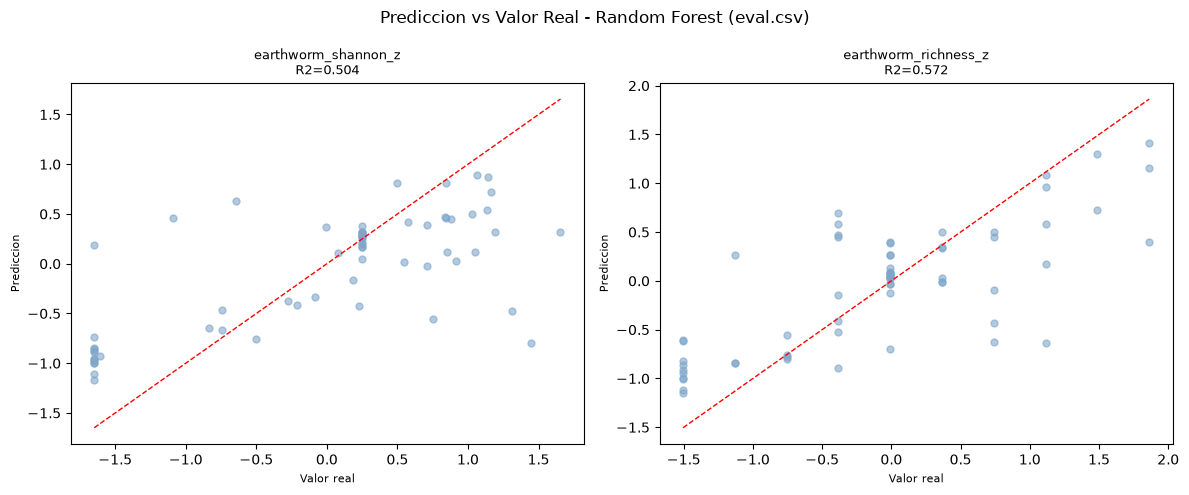

In [9]:
# Evaluacion final sobre todos los targets

print('Evaluacion final sobre eval.csv')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

for test_target in TARGETS:
    preds_eval = []
    for seed_id in range(5):
        ruta  = os.path.join(MODELS_DIR, f'rf_prod_{test_target}_m{seed_id}.pkl')
        model = joblib.load(ruta)
        preds_eval.append(model.predict(X_eval))

    y_pred_eval = np.mean(preds_eval, axis=0)
    y_true_eval = y_eval[test_target].values

    r2   = r2_score(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mae  = mean_absolute_error(y_true_eval, y_pred_eval)
    print(f'  {test_target:30} {r2:8.4f} {rmse:8.4f} {mae:8.4f}')

print('-' * 65)

# Smoke test con datos reales
# Se prueban los targets representativos

print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    df_new_data      = X_eval.sample(n=3, random_state=RANDOM_STATE)
    indices_elegidos = df_new_data.index

    for test_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
        print(f'\n  Target: {test_target}')
        print('  ' + '-' * 63)
        valores_reales = y_eval.loc[indices_elegidos, test_target].values

        votos = []
        for seed_id in range(5):
            ruta  = os.path.join(MODELS_DIR, f'rf_prod_{test_target}_m{seed_id}.pkl')
            m     = joblib.load(ruta)
            pred  = m.predict(df_new_data)
            votos.append(pred)
            print(f'  Modelo {seed_id+1} -> '
                  f'Fila {indices_elegidos[0]}: {pred[0]:.4f} | '
                  f'Fila {indices_elegidos[1]}: {pred[1]:.4f} | '
                  f'Fila {indices_elegidos[2]}: {pred[2]:.4f}')

        consenso = np.mean(votos, axis=0)
        print('  ' + '-' * 63)
        print('  Resultados detallados:')
        print('  ' + '-' * 63)
        for i, idx in enumerate(indices_elegidos):
            pred_val = consenso[i]
            real_val = valores_reales[i]
            print(f'    Fila {idx:<4} | Prediccion: {pred_val:.4f} | '
                  f'Valor Real: {real_val:.4f} | Error: {abs(pred_val-real_val):.4f}')

    print('\nSmoke test superado. El pipeline funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt in zip(axes, ['earthworm_shannon_z', 'earthworm_richness_z']):
    preds = [joblib.load(os.path.join(MODELS_DIR, f'rf_prod_{tgt}_m{i}.pkl')).predict(X_eval)
             for i in range(NUM_MODELOS)]
    yp = np.mean(preds, axis=0)
    yt = y_eval[tgt].values
    ax.scatter(yt, yp, alpha=0.6, s=25, color=PALETTE['blue'])
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - Random Forest (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()